In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

In [2]:
df = pd.read_csv("loan_approval_data.csv")

In [12]:
df.head()
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Applicant_ID        950 non-null    float64
 1   Applicant_Income    950 non-null    float64
 2   Coapplicant_Income  950 non-null    float64
 3   Employment_Status   950 non-null    object 
 4   Age                 950 non-null    float64
 5   Marital_Status      950 non-null    object 
 6   Dependents          950 non-null    float64
 7   Credit_Score        950 non-null    float64
 8   Existing_Loans      950 non-null    float64
 9   DTI_Ratio           950 non-null    float64
 10  Savings             950 non-null    float64
 11  Collateral_Value    950 non-null    float64
 12  Loan_Amount         950 non-null    float64
 13  Loan_Term           950 non-null    float64
 14  Loan_Purpose        950 non-null    object 
 15  Property_Area       950 non-null    object 
 16  Educati

Applicant_ID          50
Applicant_Income      50
Coapplicant_Income    50
Employment_Status     50
Age                   50
Marital_Status        50
Dependents            50
Credit_Score          50
Existing_Loans        50
DTI_Ratio             50
Savings               50
Collateral_Value      50
Loan_Amount           50
Loan_Term             50
Loan_Purpose          50
Property_Area         50
Education_Level       50
Gender                50
Employer_Category     50
Loan_Approved         50
dtype: int64

Handle Missing Values

In [13]:
numerical_cols = df.select_dtypes(include=["number"]).columns
categorical_cols = df.select_dtypes(include=["object"]).columns

In [15]:
from sklearn.impute import SimpleImputer
num_imp = SimpleImputer(strategy="mean")
df[numerical_cols]= num_imp.fit_transform(df[numerical_cols])


In [17]:
cat_imp = SimpleImputer(strategy="most_frequent")
df[categorical_cols] = cat_imp.fit_transform(df[categorical_cols])

In [18]:
df.head()
df.isnull().sum()

Applicant_ID          0
Applicant_Income      0
Coapplicant_Income    0
Employment_Status     0
Age                   0
Marital_Status        0
Dependents            0
Credit_Score          0
Existing_Loans        0
DTI_Ratio             0
Savings               0
Collateral_Value      0
Loan_Amount           0
Loan_Term             0
Loan_Purpose          0
Property_Area         0
Education_Level       0
Gender                0
Employer_Category     0
Loan_Approved         0
dtype: int64

In [19]:
df.head()

,Applicant_ID,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,1.0,17795.0,1387.0,Salaried,51.0,Married,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,84.0,Personal,Urban,Not Graduate,Female,Private,No
1,2.0,2860.0,2679.0,Salaried,46.0,Married,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,48.0,Car,Semiurban,Graduate,Male,Private,No
2,3.0,7390.0,2106.0,Salaried,25.0,Single,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,72.0,Business,Urban,Graduate,Female,Government,Yes
3,4.0,13964.0,8173.0,Salaried,40.0,Married,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,60.0,Business,Rural,Graduate,Female,Government,No
4,5.0,13284.0,4223.0,Self-employed,31.0,Single,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,72.0,Car,Urban,Graduate,Male,Private,Yes


EDA

## categorical and numerical
## categorial - pie , bar
## numerical - histogram
## outliers - boxplot


Text(0.5, 1.0, 'Is loan approved or not?')

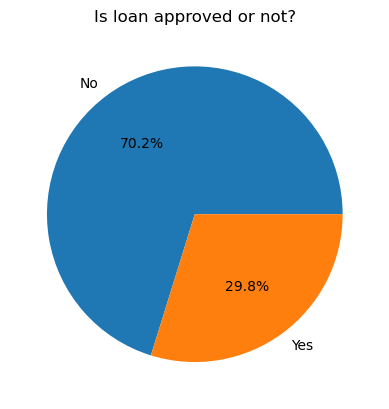

In [21]:
# how balanced our classes are
classes_count = df["Loan_Approved"].value_counts()

plt.pie(classes_count, labels=["No","Yes"],autopct="%1.1f%%")
plt.title("Is loan approved or not?")

[Text(0, 0, '722'), Text(0, 0, '278')]

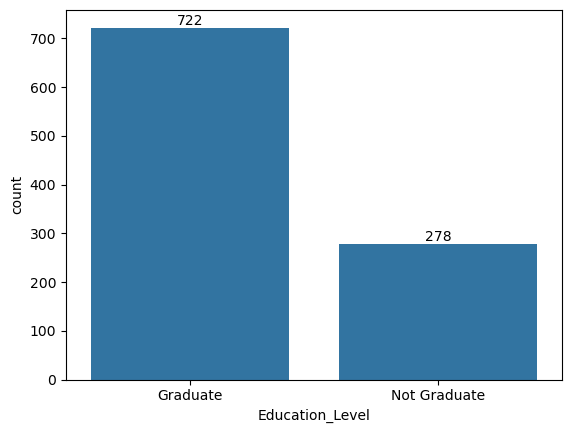

In [24]:
edu_cnt = df["Education_Level"].value_counts()
ax = sns.barplot(edu_cnt)
ax.bar_label(ax.containers[0])

<Axes: xlabel='Applicant_Income', ylabel='Count'>

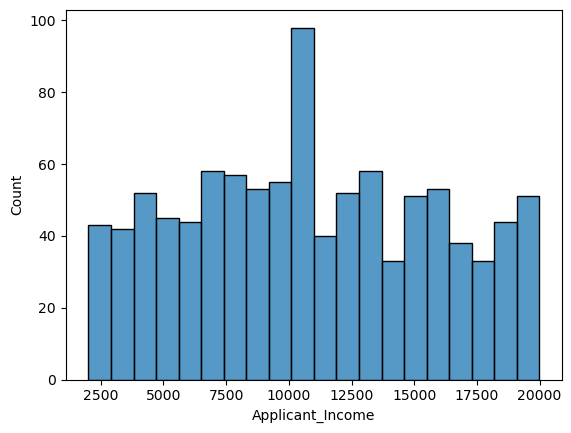

In [25]:
sns.histplot(
    data = df,
    x="Applicant_Income",
    bins=20
)

<Axes: xlabel='Coapplicant_Income', ylabel='Count'>

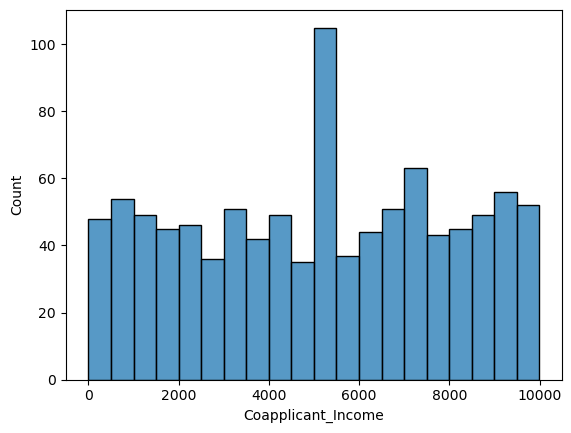

In [26]:
sns.histplot(
    data = df,
    x="Coapplicant_Income",
    bins=20
)

<Axes: xlabel='Loan_Approved', ylabel='Applicant_Income'>

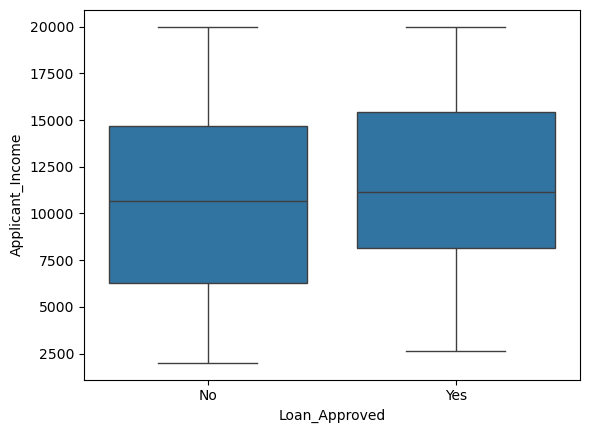

In [29]:
sns.boxplot(
    data = df,
    x="Loan_Approved",
    y="Applicant_Income",
   
)

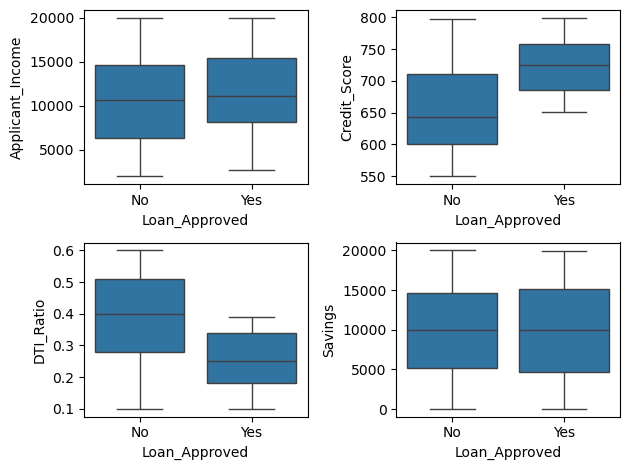

In [30]:
fig,axes = plt.subplots(2,2)
sns.boxplot(ax=axes[0,0],data=df,x="Loan_Approved",y="Applicant_Income")
sns.boxplot(ax=axes[0,1],data=df,x="Loan_Approved",y="Credit_Score")
sns.boxplot(ax=axes[1,0],data=df,x="Loan_Approved",y="DTI_Ratio")
sns.boxplot(ax=axes[1,1],data=df,x="Loan_Approved",y="Savings")

plt.tight_layout()



<Axes: xlabel='Credit_Score', ylabel='Count'>

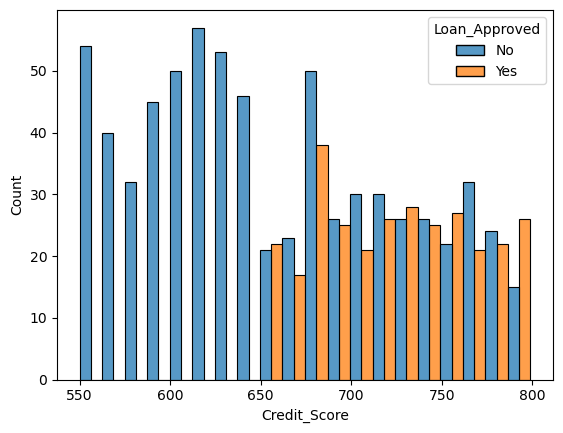

In [32]:
# Credit Score with loan Approved
sns.histplot(
    data=df,
    x="Credit_Score",
    hue="Loan_Approved",
    bins=20,
    multiple="dodge"
)

<Axes: xlabel='Applicant_Income', ylabel='Count'>

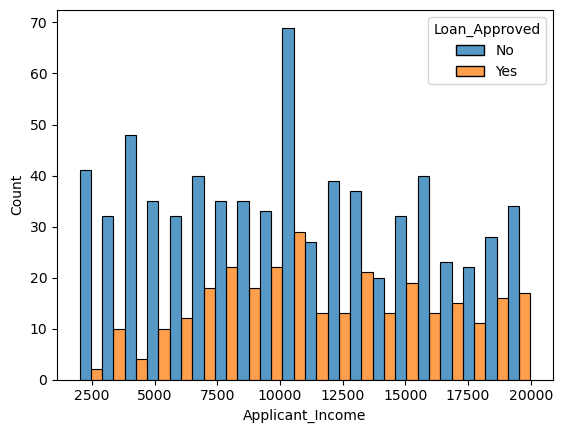

In [33]:
sns.histplot(
    data=df,
    x="Applicant_Income",
    hue="Loan_Approved",
    bins=20,
    multiple="dodge"
)

In [34]:
df = df.drop("Applicant_ID",axis=1)

In [35]:
df.head()

,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,17795.0,1387.0,Salaried,51.0,Married,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,84.0,Personal,Urban,Not Graduate,Female,Private,No
1,2860.0,2679.0,Salaried,46.0,Married,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,48.0,Car,Semiurban,Graduate,Male,Private,No
2,7390.0,2106.0,Salaried,25.0,Single,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,72.0,Business,Urban,Graduate,Female,Government,Yes
3,13964.0,8173.0,Salaried,40.0,Married,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,60.0,Business,Rural,Graduate,Female,Government,No
4,13284.0,4223.0,Self-employed,31.0,Single,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,72.0,Car,Urban,Graduate,Male,Private,Yes


ENCODING

In [36]:
df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 19 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Applicant_Income    1000 non-null   float64
 1   Coapplicant_Income  1000 non-null   float64
 2   Employment_Status   1000 non-null   object 
 3   Age                 1000 non-null   float64
 4   Marital_Status      1000 non-null   object 
 5   Dependents          1000 non-null   float64
 6   Credit_Score        1000 non-null   float64
 7   Existing_Loans      1000 non-null   float64
 8   DTI_Ratio           1000 non-null   float64
 9   Savings             1000 non-null   float64
 10  Collateral_Value    1000 non-null   float64
 11  Loan_Amount         1000 non-null   float64
 12  Loan_Term           1000 non-null   float64
 13  Loan_Purpose        1000 non-null   object 
 14  Property_Area       1000 non-null   object 
 15  Education_Level     1000 non-null   object 
 16  Gender 

In [47]:
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
le = LabelEncoder()
df["Education_Level"] = le.fit_transform(df["Education_Level"])
df["Loan_Approved"] = le.fit_transform(df["Loan_Approved"])

In [48]:
df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 29 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Applicant_Income                 1000 non-null   float64
 1   Coapplicant_Income               1000 non-null   float64
 2   Age                              1000 non-null   float64
 3   Dependents                       1000 non-null   float64
 4   Credit_Score                     1000 non-null   float64
 5   Existing_Loans                   1000 non-null   float64
 6   DTI_Ratio                        1000 non-null   float64
 7   Savings                          1000 non-null   float64
 8   Collateral_Value                 1000 non-null   float64
 9   Loan_Amount                      1000 non-null   float64
 10  Loan_Term                        1000 non-null   float64
 11  Education_Level                  1000 non-null   int64  
 12  Loan_Approved        

In [43]:
cols = ["Employment_Status", "Marital_Status", "Loan_Purpose", "Property_Area", "Gender", "Employer_Category"]

ohe = OneHotEncoder(drop="first",sparse_output=False, handle_unknown="ignore")
encoded = ohe.fit_transform(df[cols])
encoded_df = pd.DataFrame(encoded,columns=ohe.get_feature_names_out(cols),index=df.index)
df = pd.concat([df.drop(columns=cols),encoded_df],axis=1)

KeyError: "None of [Index(['Employment_Status', 'Marital_Status', 'Loan_Purpose', 'Property_Area',\n       'Gender', 'Employer_Category'],\n      dtype='object')] are in the [columns]"

In [49]:
df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 29 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Applicant_Income                 1000 non-null   float64
 1   Coapplicant_Income               1000 non-null   float64
 2   Age                              1000 non-null   float64
 3   Dependents                       1000 non-null   float64
 4   Credit_Score                     1000 non-null   float64
 5   Existing_Loans                   1000 non-null   float64
 6   DTI_Ratio                        1000 non-null   float64
 7   Savings                          1000 non-null   float64
 8   Collateral_Value                 1000 non-null   float64
 9   Loan_Amount                      1000 non-null   float64
 10  Loan_Term                        1000 non-null   float64
 11  Education_Level                  1000 non-null   int64  
 12  Loan_Approved        

In [50]:
df.dtypes

Applicant_Income                   float64
Coapplicant_Income                 float64
Age                                float64
Dependents                         float64
Credit_Score                       float64
Existing_Loans                     float64
DTI_Ratio                          float64
Savings                            float64
Collateral_Value                   float64
Loan_Amount                        float64
Loan_Term                          float64
Education_Level                      int64
Loan_Approved                        int64
Education_level                      int64
Employment_Status_Salaried         float64
Employment_Status_Self-employed    float64
Employment_Status_Unemployed       float64
Marital_Status_Single              float64
Loan_Purpose_Car                   float64
Loan_Purpose_Education             float64
Loan_Purpose_Home                  float64
Loan_Purpose_Personal              float64
Property_Area_Semiurban            float64
Property_Ar

Correlation Heatmap

<Axes: >

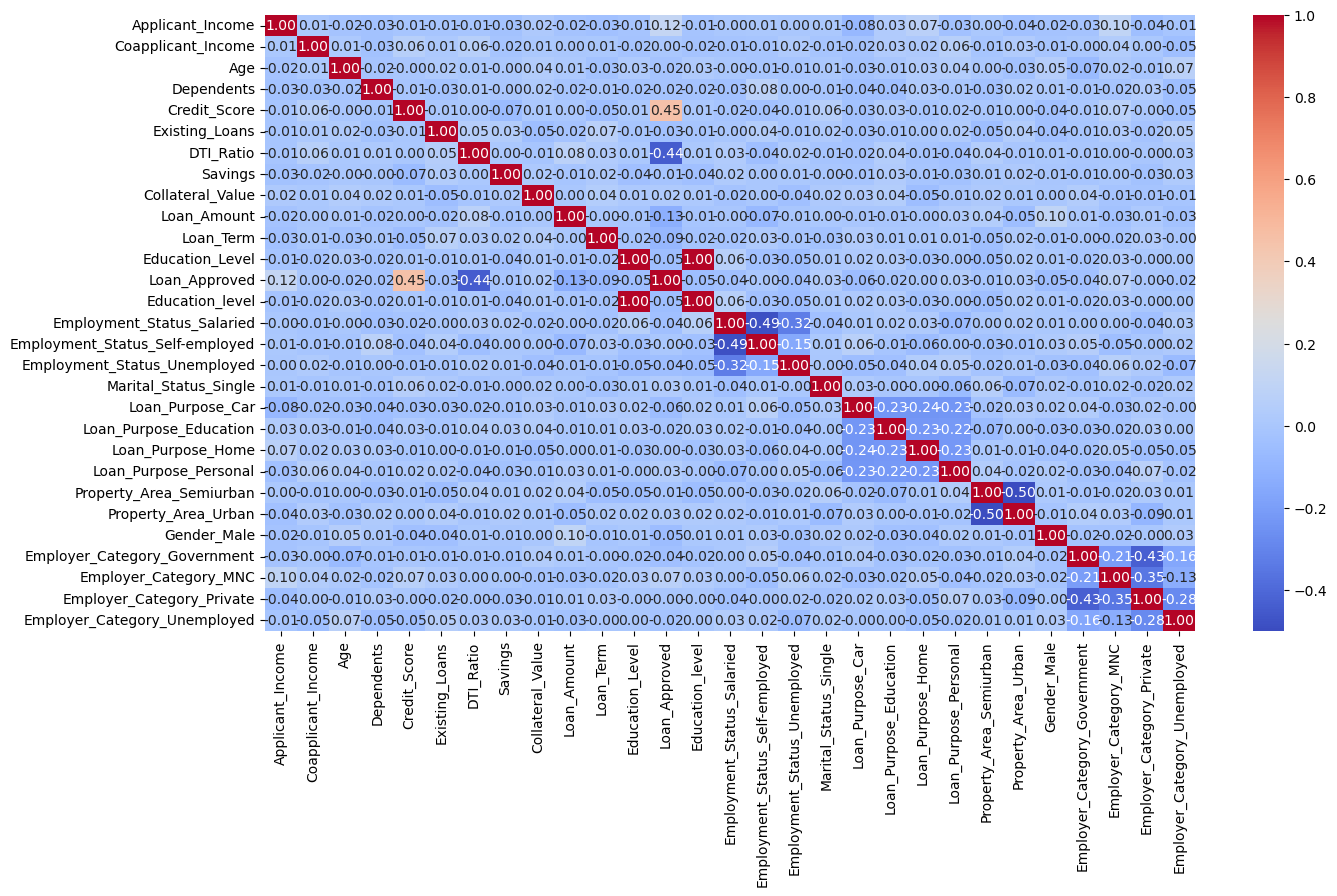

In [51]:
num_cols = df.select_dtypes(include="number")
corr_matrix = num_cols.corr()

plt.figure(figsize=(15,8))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap = "coolwarm"
)

In [52]:
num_cols.corr()["Loan_Approved"].sort_values(ascending=False)

Loan_Approved                      1.000000
Credit_Score                       0.451175
Applicant_Income                   0.119796
Employer_Category_MNC              0.069049
Loan_Purpose_Personal              0.034043
Marital_Status_Single              0.030182
Property_Area_Urban                0.025963
Collateral_Value                   0.021868
Coapplicant_Income                 0.004230
Loan_Purpose_Home                  0.002118
Employment_Status_Self-employed   -0.001337
Employer_Category_Private         -0.003347
Property_Area_Semiurban           -0.012967
Savings                           -0.013437
Loan_Purpose_Education            -0.016684
Employer_Category_Unemployed      -0.021468
Age                               -0.022343
Dependents                        -0.023811
Existing_Loans                    -0.034794
Employer_Category_Government      -0.039187
Employment_Status_Salaried        -0.041428
Employment_Status_Unemployed      -0.044464
Education_level                 

Train-Test-Split + Feature Scaling

In [53]:
X=df.drop("Loan_Approved",axis=1)
y=df["Loan_Approved"]

In [54]:
y.head()

0    0
1    0
2    1
3    0
4    1
Name: Loan_Approved, dtype: int64

In [55]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [56]:
X_test.head()

,Applicant_Income,Coapplicant_Income,Age,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,...,Loan_Purpose_Education,Loan_Purpose_Home,Loan_Purpose_Personal,Property_Area_Semiurban,Property_Area_Urban,Gender_Male,Employer_Category_Government,Employer_Category_MNC,Employer_Category_Private,Employer_Category_Unemployed
521,13023.0,6675.0,53.000000,3.0,628.0,3.0,0.347263,10051.000000,26309.0,22947.000000,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0
737,15917.0,6787.0,42.000000,0.0,588.0,4.0,0.410000,922.000000,13476.0,20522.825263,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
740,7560.0,3530.0,52.000000,3.0,606.0,0.0,0.580000,9940.452632,21795.0,5876.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
660,19022.0,574.0,59.000000,0.0,725.0,4.0,0.410000,1463.000000,44498.0,8433.000000,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
411,4967.0,5797.0,39.971579,3.0,697.0,4.0,0.580000,1095.000000,3017.0,33926.000000,...,0.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0


In [57]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [58]:
X_test_scaled

array([[ 0.42610546,  0.55091079,  1.19037073, ..., -0.41388776,
         1.16316   , -0.30723158],
       [ 1.00971366,  0.58995935,  0.18392964, ..., -0.41388776,
         1.16316   , -0.30723158],
       [-0.67557096, -0.54558674,  1.09887608, ..., -0.41388776,
         1.16316   , -0.30723158],
       ...,
       [-0.67980585, -0.10106072,  1.28186537, ..., -0.41388776,
         1.16316   , -0.30723158],
       [-0.37650705, -0.97825874, -0.54802752, ..., -0.41388776,
        -0.85972695, -0.30723158],
       [-0.73647272, -1.24497436,  0.73289751, ..., -0.41388776,
         1.16316   , -0.30723158]], shape=(200, 28))

Train and Evaluate model

In [59]:
# Logistic Regression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix,accuracy_score,precision_score,recall_score,f1_score

log_model = LogisticRegression()
log_model.fit(X_train_scaled,y_train)

y_pred = log_model.predict(X_test_scaled)

# Evaluation
print("Logistic Regression model")
print("Precision: ",precision_score(y_test,y_pred))
print("Recall ",recall_score(y_test,y_pred))
print("F1 score ", f1_score(y_test,y_pred))
print("Accuracy ",accuracy_score(y_test,y_pred))
print("CM ",confusion_matrix(y_test,y_pred))


Logistic Regression model
Precision:  0.7833333333333333
Recall  0.7704918032786885
F1 score  0.7768595041322314
Accuracy  0.865
CM  [[126  13]
 [ 14  47]]


In [67]:
# KNN
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix,accuracy_score,precision_score,recall_score,f1_score

knn_model = KNeighborsClassifier(n_neighbors=9)
knn_model.fit(X_train_scaled,y_train)

y_pred = knn_model.predict(X_test_scaled)

# Evaluation
print("KNN model")
print("Precision: ",precision_score(y_test,y_pred))
print("Recall ",recall_score(y_test,y_pred))
print("F1 score ", f1_score(y_test,y_pred))
print("Accuracy ",accuracy_score(y_test,y_pred))
print("CM ",confusion_matrix(y_test,y_pred))


KNN model
Precision:  0.7027027027027027
Recall  0.4262295081967213
F1 score  0.5306122448979592
Accuracy  0.77
CM  [[128  11]
 [ 35  26]]


In [69]:
# Naive Bayes

from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import confusion_matrix,accuracy_score,precision_score,recall_score,f1_score

nb_model = GaussianNB()
nb_model.fit(X_train_scaled,y_train)

y_pred = nb_model.predict(X_test_scaled)

# Evaluation
print("Naive Bayes model")
print("Precision: ",precision_score(y_test,y_pred))
print("Recall ",recall_score(y_test,y_pred))
print("F1 score ", f1_score(y_test,y_pred))
print("Accuracy ",accuracy_score(y_test,y_pred))
print("CM ",confusion_matrix(y_test,y_pred))


Naive Bayes model
Precision:  0.8245614035087719
Recall  0.7704918032786885
F1 score  0.7966101694915254
Accuracy  0.88
CM  [[129  10]
 [ 14  47]]


Best Model Based on Precision Naive bayes

Feature Engineering

In [70]:
# Add or transform features
df["DTI_Ratio_sq"] = df["DTI_Ratio"] **2
df["Credit_Score_sq"] = df["Credit_Score"] ** 2

X = df.drop(columns=["Loan_Approved","Credit_Score","DTI_Ratio"])
y = df["Loan_Approved"]

# Train test split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

# Scaling
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [71]:
# Logistic Regression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix,accuracy_score,precision_score,recall_score,f1_score

log_model = LogisticRegression()
log_model.fit(X_train_scaled,y_train)

y_pred = log_model.predict(X_test_scaled)

# Evaluation
print("Logistic Regression model")
print("Precision: ",precision_score(y_test,y_pred))
print("Recall ",recall_score(y_test,y_pred))
print("F1 score ", f1_score(y_test,y_pred))
print("Accuracy ",accuracy_score(y_test,y_pred))
print("CM ",confusion_matrix(y_test,y_pred))


Logistic Regression model
Precision:  0.7903225806451613
Recall  0.8032786885245902
F1 score  0.7967479674796748
Accuracy  0.875
CM  [[126  13]
 [ 12  49]]


In [72]:
# KNN
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix,accuracy_score,precision_score,recall_score,f1_score

knn_model = KNeighborsClassifier(n_neighbors=9)
knn_model.fit(X_train_scaled,y_train)

y_pred = knn_model.predict(X_test_scaled)

# Evaluation
print("KNN model")
print("Precision: ",precision_score(y_test,y_pred))
print("Recall ",recall_score(y_test,y_pred))
print("F1 score ", f1_score(y_test,y_pred))
print("Accuracy ",accuracy_score(y_test,y_pred))
print("CM ",confusion_matrix(y_test,y_pred))


KNN model
Precision:  0.7209302325581395
Recall  0.5081967213114754
F1 score  0.5961538461538461
Accuracy  0.79
CM  [[127  12]
 [ 30  31]]


In [73]:
# Naive Bayes

from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import confusion_matrix,accuracy_score,precision_score,recall_score,f1_score

nb_model = GaussianNB()
nb_model.fit(X_train_scaled,y_train)

y_pred = nb_model.predict(X_test_scaled)

# Evaluation
print("Naive Bayes model")
print("Precision: ",precision_score(y_test,y_pred))
print("Recall ",recall_score(y_test,y_pred))
print("F1 score ", f1_score(y_test,y_pred))
print("Accuracy ",accuracy_score(y_test,y_pred))
print("CM ",confusion_matrix(y_test,y_pred))


Naive Bayes model
Precision:  0.8103448275862069
Recall  0.7704918032786885
F1 score  0.7899159663865546
Accuracy  0.875
CM  [[128  11]
 [ 14  47]]
